In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import gc
import itertools
import tqdm as notebook_tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pyarrow.parquet as pq
import pickle
import datetime

from tqdm.auto import tqdm

from sklearn.metrics import RocCurveDisplay, roc_curve, auc, classification_report, confusion_matrix
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier

from utils import reduce_mem_usage, plot_confusion_matrix, compute_weights

###  Обучение моделей на всех признаках

    Параметры модели взяты из предварительного анализа выполненно с помощью lightautoml (см. ноутбук Auto_ML.ipynb).
    Поскольку все данные тренеровочного датасета не помещаются в оперативную память, будет обучатся 3 модели (по числу row_groups в файле 'data_train_std.pq').
    
    Итоговое предсказание определяется одним из двух способ:
1. **Равные веса**: путем определения средней веротности.
2. **Пропорциональные веса**: путем суммирования произведения вероятностей на веса. Веса определяются как отношение записей в конкретной row_group к общему количеству записей в тренеровочном датасете.

In [759]:
PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'feature_fraction': 0.49, 
    'num_leaves': 50, 
    'learning_rate': 0.039,
    'bagging_fraction': 0.4, 
    'min_sum_hessian_in_leaf': 1, 
    'reg_alpha': 10, 
    'reg_lambda': 1,
    'n_estimators': 236,
    'min_data_in_leaf': 15,
}

In [760]:
pf = pq.ParquetFile(r'../prep_data/data_train_std.pq')
for i in range(pf.num_row_groups):
    num_rows_in_rg = pf.metadata.row_group(i).num_rows
    print(f'Row group {i} содержит {num_rows_in_rg} строк')

Row group 0 содержит 1048576 строк
Row group 1 содержит 1048576 строк
Row group 2 содержит 302848 строк


In [761]:
models = {}

In [762]:
datetime.datetime.now()

datetime.datetime(2026, 10, 1, 18, 29, 29, 719187)

In [763]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch.drop(['id', 'flag'], axis=1)
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)
    file_name = key + '.pkl'

    with open(file_name, 'wb') as f:
        pickle.dump(bst, f)
    print(f'Модель сохранена в {file_name}')

    models[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 386), размер X_val: (209716, 386)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.214902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5230
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 375
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Модель сохранена в lgb_model_0.pkl
Читаем row group: 1
Размер X_train: (838860, 386), размер X_val: (209716, 386)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51834019 14.13126242]
[LightGBM] [Info] Number

In [764]:
models

{'lgb_model_0': <lightgbm.basic.Booster at 0x733fc82541c0>,
 'lgb_model_1': <lightgbm.basic.Booster at 0x733fd02e4c70>,
 'lgb_model_2': <lightgbm.basic.Booster at 0x733fa1329690>}

In [765]:
tf = pq.ParquetFile(r'../prep_data/data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test.drop(['id', 'flag'], axis=1)
X_test.shape, y_test.shape

((600000, 386), (600000,))

In [766]:
y_pred_proba = {}

In [767]:
for model in models.keys():
    y_pred = models[model].predict(X_test)
    y_pred_proba[model] = y_pred

In [768]:
y_pred_proba

{'lgb_model_0': array([0.73063934, 0.45153608, 0.66898641, ..., 0.22607984, 0.28409825,
        0.29550395]),
 'lgb_model_1': array([0.75802308, 0.45955657, 0.56018632, ..., 0.27292545, 0.28130526,
        0.30695623]),
 'lgb_model_2': array([0.73632765, 0.52208069, 0.40950657, ..., 0.16275839, 0.27251692,
        0.29216225])}

In [769]:
df_preds = pd.DataFrame(y_pred_proba)

In [770]:
df_preds.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.730639,0.758023,0.736328
1,0.451536,0.459557,0.522081
2,0.668986,0.560186,0.409507
3,0.474315,0.497057,0.486637
4,0.577662,0.557178,0.571193


In [771]:
model_weights = []

In [772]:
for i in range(pf.num_row_groups):
    model_weights.append(pf.metadata.row_group(i).num_rows / pf.metadata.num_rows)
model_weights  

[0.43690666666666667, 0.43690666666666667, 0.12618666666666667]

In [773]:
df_preds['mid'] = (df_preds['lgb_model_0'] + df_preds['lgb_model_1'] + df_preds['lgb_model_2']) / 3

In [774]:
df_preds['weights'] = df_preds['lgb_model_0'] * model_weights[0] + df_preds['lgb_model_1'] * model_weights[1] + df_preds['lgb_model_2'] * model_weights[2]

In [775]:
df_preds['mid_binary_50'] = (df_preds['mid'] > 0.5).astype(int)
df_preds['weights_binary'] = (df_preds['weights'] > 0.5).astype(int)

In [776]:
df_preds['true'] = y_test
df_preds.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,weights,mid_binary_50,weights_binary,true
0,0.730639,0.758023,0.736328,0.741663,0.743321,1,1,0
1,0.451536,0.459557,0.522081,0.477724,0.463942,0,0,0
2,0.668986,0.560186,0.409507,0.546226,0.588708,1,1,0
3,0.474315,0.497057,0.486637,0.486003,0.485806,0,0,0
4,0.577662,0.557178,0.571193,0.568678,0.567896,1,1,0


In [777]:
df_preds[df_preds['mid_binary_50'] != df_preds['weights_binary']]

,lgb_model_0,lgb_model_1,lgb_model_2,mid,weights,mid_binary_50,weights_binary,true
11,0.514233,0.465139,0.520970,0.500114,0.493633,1,0,0
64,0.515614,0.526412,0.457146,0.499724,0.512954,0,1,0
79,0.476194,0.479579,0.589559,0.515110,0.491978,1,0,0
81,0.493535,0.556462,0.439188,0.496395,0.514170,0,1,0
148,0.506712,0.508435,0.459146,0.491431,0.501463,0,1,0
...,...,...,...,...,...,...,...,...
599895,0.489377,0.525040,0.473456,0.495958,0.502949,0,1,0
599903,0.487890,0.543966,0.418260,0.483372,0.503603,0,1,0
599917,0.534361,0.502601,0.394844,0.477269,0.502880,0,1,0
599950,0.437094,0.540709,0.574207,0.517337,0.499666,1,0,0


In [778]:
df_preds.to_csv('lgb_preds.csv')

In [779]:
print(classification_report(df_preds['true'], df_preds['mid_binary_50']))

              precision    recall  f1-score   support

           0       0.98      0.62      0.76    578712
           1       0.06      0.70      0.12     21288

    accuracy                           0.62    600000
   macro avg       0.52      0.66      0.44    600000
weighted avg       0.95      0.62      0.74    600000



In [780]:
print(classification_report(df_preds['true'], df_preds['weights_binary']))

              precision    recall  f1-score   support

           0       0.98      0.61      0.75    578712
           1       0.06      0.71      0.11     21288

    accuracy                           0.61    600000
   macro avg       0.52      0.66      0.43    600000
weighted avg       0.95      0.61      0.73    600000



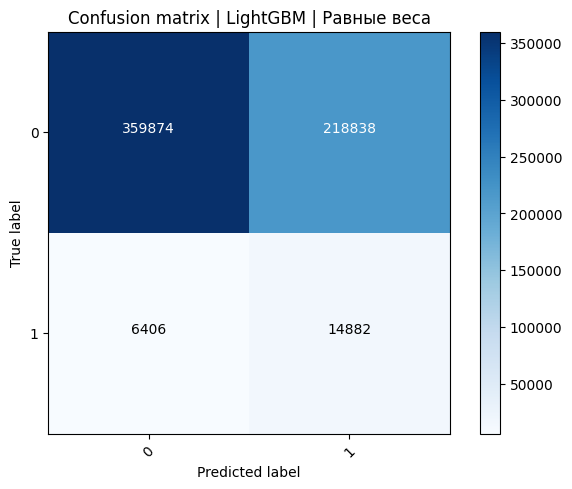

In [781]:
plot_confusion_matrix(confusion_matrix(df_preds['true'], df_preds['mid_binary_50']), classes=['0','1'],
                      title='Confusion matrix | LightGBM | Равные веса')
#plt.savefig('pictures/LightGBM_model_mid.png', bbox_inches='tight')

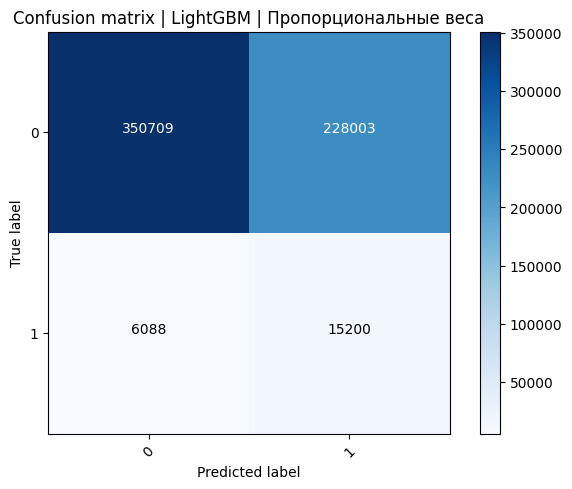

In [782]:
plot_confusion_matrix(confusion_matrix(df_preds['true'], df_preds['weights_binary']), classes=['0','1'],
                      title='Confusion matrix | LightGBM | Пропорциональные веса')
#plt.savefig('pictures/LightGBM_model_weights.png', bbox_inches='tight')

Text(0.5, 1.0, 'LightGBM | Mid | Равные веса')

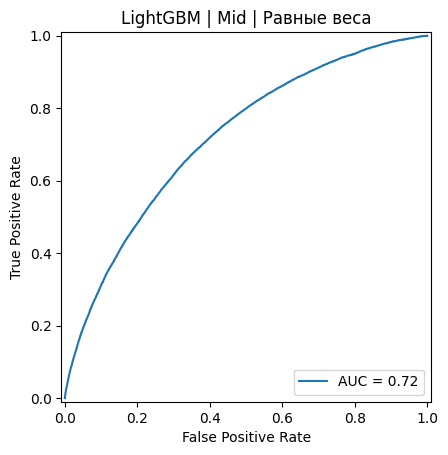

In [783]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds['true'], df_preds['mid'])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('LightGBM | Mid | Равные веса')
#plt.savefig('pictures/LightGBM_model_roc_mid.png', bbox_inches='tight');

In [784]:
roc_auc

0.7181933249635823

Text(0.5, 1.0, 'LightGBM | Mid | Равные веса')

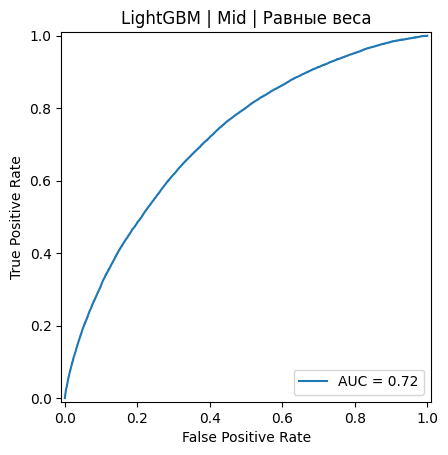

In [785]:
fpr, tpr, _ = roc_curve(df_preds['true'], df_preds['weights'])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('LightGBM | Mid | Равные веса')
#plt.savefig('pictures/LightGBM_model_roc_weights.png', bbox_inches='tight')

Модель с пропорциональнми весами показывает, чуть лучшее качество, но AUC не достаточен.

In [786]:
roc_auc

0.7193224208941122

### Отбор признаков и обучение моделей на них

    Для улучшения качества модели попробую провести отбор признаков для обучения по критерию .feature_importance обученных на предыдущем шаге моделей. Важность определяется аналогично двумя методами: равные веса и пропорциональные веса.

In [787]:
feat_dict = {}

In [788]:
for model in models.keys():
    feat_dict[model] = models[model].feature_importance(importance_type='gain')
    feature_names = models[model].feature_name() 

In [789]:
df_feat = pd.DataFrame(feat_dict, index=feature_names)

In [790]:
df_feat['mid'] = (df_feat['lgb_model_0'] + df_feat['lgb_model_1'] + df_feat['lgb_model_2']) / 3
df_feat['weights'] = df_feat['lgb_model_0'] * model_weights[0] + df_feat['lgb_model_1'] * model_weights[1] + df_feat['lgb_model_2'] * model_weights[2]

In [791]:
df_feat.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,weights
pre_pterm_14_std,7913.688690,9376.933487,4272.112202,7187.578126,8093.471698
pre_pterm_15_std,1464.547501,1812.719391,1642.118309,1639.795067,1639.073189
pre_pterm_16_std,833.934906,1598.516499,1283.025311,1238.492238,1224.654922
pre_pterm_17_std,1460.516094,2053.263012,1872.700396,1795.493167,1771.503337
pre_fterm_1_std,3301.447586,2278.025627,1183.904501,2254.459238,2587.102006


In [792]:
df_sorted_mid = df_feat.sort_values(by='mid', ascending=False)
top_50_mid = df_sorted_mid.index[:50]

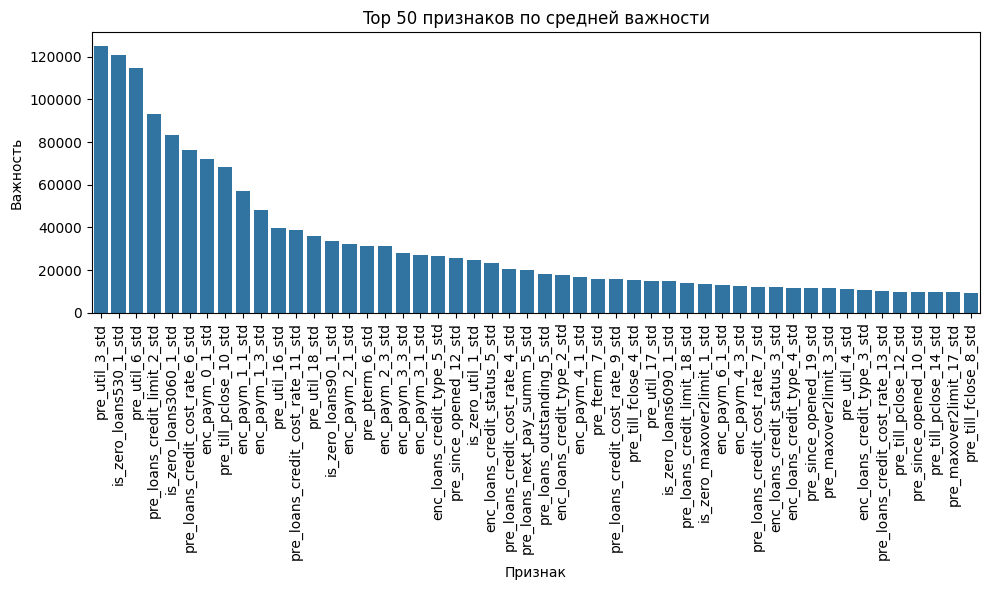

In [793]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted_mid.head(50), x=top_50_mid, y='mid')
plt.title('Top 50 признаков по средней важности')
plt.xlabel('Признак')
plt.xticks(rotation=90)
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

In [794]:
df_sorted_weights = df_feat.sort_values(by='weights', ascending=False)
top_50_wts = df_sorted_weights.index[:50]

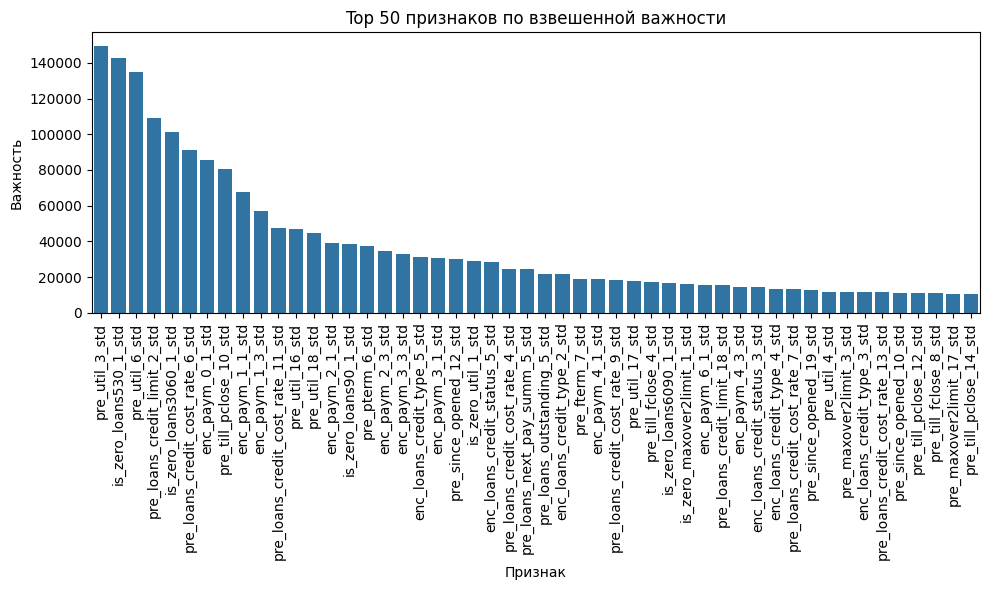

In [795]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted_weights.head(50), x=top_50_wts, y='weights')
plt.title('Top 50 признаков по взвешенной важности')
plt.xlabel('Признак')
plt.xticks(rotation=90)
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

Отличия в важности имеются, но не значительны (первое отличие появляется на 12 индексе). Основной вклад вносят следующие 10 признаков:
1. 'is_zero_loans530_1_std' - флаг, нет просрочек от 5 до 30 дней;
2. 'pre_util_3_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 3)
3. 'pre_util_6_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 6)
4. 'pre_loans_credit_limit_2_std' - кридитный лимит (бинаризованное значение 2)
5. 'pre_loans_credit_cost_rate_6_std' - полная стоимость кредита (бинаризованное значение 6)
6. 'enc_paym_0_1_std' - статус ежемесячного платежа за последний месяц (закодированное значение 1),
7. 'pre_till_pclose_10_std' - плановое количиство дней с даты сбора данных до даты закрытия (бинаризованное значение 10),
8. 'is_zero_loans3060_1_std' - флаг, нет просрочек от 30 до 60 дней;
9. 'enc_paym_1_1_std' статус ежемесячного платежа за последние два месяца (закодированное значение 1),
10. 'pre_util_16_std' - отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризованное значение 16)


#### Обучение моделей на разном количестве признаков, отсортировванных по важности. Усреднение моделей равными весами.

In [796]:
top_mid = df_sorted_mid.index[:130]

In [797]:
models_top_mid = {}

In [798]:
tf = pq.ParquetFile(r'../prep_data/data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test[top_mid]
X_test.shape, y_test.shape

((600000, 130), (600000,))

In [799]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch[top_mid]
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)

    models_top_mid[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2896
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Читаем row group: 1
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51834019 14.13126242]
[LightGBM] [Info] Number of positive: 29681, number of nega

In [800]:
y_proba_mid = {}
for model in models_top_mid.keys():
    y_pred = models_top_mid[model].predict(X_test)
    y_proba_mid[model] = y_pred

In [801]:
df_preds_mid = pd.DataFrame(y_proba_mid)
df_preds_mid.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.741850,0.734720,0.747457
1,0.278127,0.210117,0.307063
2,0.488397,0.430217,0.384480
3,0.448580,0.410442,0.518567
4,0.496827,0.482182,0.567385


In [802]:
df_preds_mid['mid'] = (df_preds_mid['lgb_model_0'] + df_preds_mid['lgb_model_1'] + df_preds_mid['lgb_model_2']) / 3

In [803]:
df_preds_mid['mid_binary'] = (df_preds_mid['mid'] > 0.5).astype(int)

In [804]:
df_preds_mid['true'] = y_test

In [805]:
df_preds_mid.head()

,lgb_model_0,lgb_model_1,lgb_model_2,mid,mid_binary,true
0,0.741850,0.734720,0.747457,0.741342,1,0
1,0.278127,0.210117,0.307063,0.265103,0,0
2,0.488397,0.430217,0.384480,0.434365,0,0
3,0.448580,0.410442,0.518567,0.459196,0,0
4,0.496827,0.482182,0.567385,0.515465,1,0


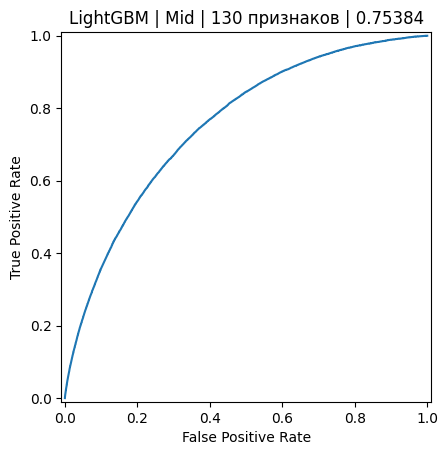

In [806]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds_mid['true'], df_preds_mid['mid'])
roc_auc_mid = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.title(f'LightGBM | Mid | 130 признаков | {roc_auc_mid:.5f}')
plt.savefig('pictures/LightGBM_model_roc_top_mid.png', bbox_inches='tight');

Существенное увеличение AUC = 0.75384 удалось добится на первых 130 признаках.

#### Обучение моделей на разном количестве признаков, отсортировванных по важности. Усреднение моделей равными весами.

In [807]:
top_wts = df_sorted_weights.index[:130]

In [808]:
models_top_wts = {}

In [809]:
tf = pq.ParquetFile(r'../prep_data/data_test_std.pq')
table = tf.read_row_group(0)
X_test = table.to_pandas()
y_test = X_test['flag']
X_test = X_test[top_wts]
X_test.shape, y_test.shape

((600000, 130), (600000,))

In [810]:
for row_group in range(pf.num_row_groups):
    print(f'Читаем row group: {row_group}')
    table = pf.read_row_group(row_group)
    batch = table.to_pandas()
    X = batch[top_wts]
    y = batch['flag']
    
    del batch
    gc.collect()

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y
    )
    print(f'Размер X_train: {X_train.shape}, размер X_val: {X_val.shape}')
    print(f'Размер y_train: {y_train.shape}, размер y_val: {y_val.shape}')

    del X, y
    gc.collect()

    val_counts = 0.

    weights = compute_weights(y_train)
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights)
    validation_data = train_data.create_valid(X_val, label=y_val)

    bst = lgb.train(PARAMS, train_data, num_boost_round=2000, valid_sets=[validation_data])

    key = 'lgb_model_' + str(row_group)

    models_top_wts[key] = bst

    del bst
    gc.collect()

Читаем row group: 0
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51829216 14.16706073]
[LightGBM] [Info] Number of positive: 29606, number of negative: 809254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2893
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Читаем row group: 1
Размер X_train: (838860, 130), размер X_val: (209716, 130)
Размер y_train: (838860,), размер y_val: (209716,)
Веса рассчитанные compute_weights: [ 0.51834019 14.13126242]
[LightGBM] [Info] Number of positive: 29681, number of nega

In [811]:
y_proba_wts = {}
for model in models_top_wts.keys():
    y_pred = models_top_wts[model].predict(X_test)
    y_proba_wts[model] = y_pred

In [812]:
df_preds_wts = pd.DataFrame(y_proba_wts)
df_preds_wts.head()

,lgb_model_0,lgb_model_1,lgb_model_2
0,0.742636,0.752972,0.742575
1,0.271045,0.214004,0.325304
2,0.473567,0.468081,0.386951
3,0.478252,0.431967,0.512253
4,0.492080,0.488169,0.556357


In [813]:
df_preds_wts['weights'] = df_preds_wts['lgb_model_0'] * model_weights[0] + df_preds_wts['lgb_model_1'] * model_weights[1] + df_preds_wts['lgb_model_2'] * model_weights[2]

In [814]:
df_preds_wts['wts_binary'] = (df_preds_wts['weights'] > 0.5).astype(int)

In [815]:
df_preds_wts['true'] = y_test

In [816]:
df_preds_wts.head()

,lgb_model_0,lgb_model_1,lgb_model_2,weights,wts_binary,true
0,0.742636,0.752972,0.742575,0.747144,1,0
1,0.271045,0.214004,0.325304,0.252970,0,0
2,0.473567,0.468081,0.386951,0.460240,0,0
3,0.478252,0.431967,0.512253,0.462320,0,0
4,0.492080,0.488169,0.556357,0.498482,0,0


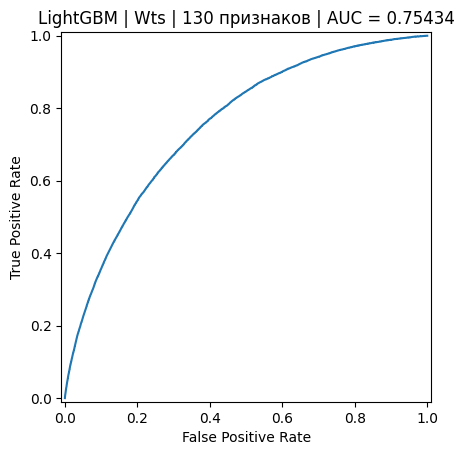

In [817]:
 # Посчитаем значение метрики AUC и построим ROC кривую
fpr, tpr, _ = roc_curve(df_preds_wts['true'], df_preds_wts['weights'])
roc_auc_wts = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.title(f'LightGBM | Wts | 130 признаков | AUC = {roc_auc_wts:.5f}')
plt.savefig('pictures/LightGBM_model_roc_top_wts.png', bbox_inches='tight');

Пропорциональное усреднение позволило несколько увелить AUC с 0.75384 до 0.75434. Максимум также на первых 130 признаках.

#### Сохранение ансамбевой модели, полученной на обучении по 130 наиболее важным признакам с пропорциональным усреднением.

In [818]:
estimators = [
    ('lgb_model_0', models_top_wts['lgb_model_0']),
    ('lgb_model_1', models_top_wts['lgb_model_1']),
    ('lgb_model_2', models_top_wts['lgb_model_2'])
]

In [819]:
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=model_weights
)

In [820]:
with open('lgd_voting_ensemble.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)